In [1]:
import pandas as pd
import numpy as np
import transformers
import torch
import os

In [2]:
print("GPU is", "available" if torch.cuda.is_available() else "NOT AVAILABLE")

if torch.cuda.is_available():
    print(f"Num GPUs available: {torch.cuda.device_count()}")
    print(f"Name of GPU: {torch.cuda.get_device_name(0)}")

GPU is available
Num GPUs available: 2
Name of GPU: Tesla T4


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import xgboost as xgb

In [4]:
train_rules = pd.read_csv("/kaggle/input/fake-or-real-the-impostor-hunt/data/train.csv")
train_rules.head()

,id,real_text_id
0,0,1
1,1,2
2,2,1
3,3,2
4,4,2


In [5]:
def read_texts_from_dir(dir_path):
  """
  Reads the texts from a given directory and saves them in the pd.DataFrame with columns ['id', 'file_1', 'file_2'].

  Params:
    dir_path (str): path to the directory with data
  """
  # Count number of directories in the provided path
  dir_count = sum(os.path.isdir(os.path.join(root, d)) for root, dirs, _ in os.walk(dir_path) for d in dirs)
  data=[0 for _ in range(dir_count)]
  print(f"Number of directories: {dir_count}")

  # For each directory, read both file_1.txt and file_2.txt and save results to the list
  i=0
  for folder_name in sorted(os.listdir(dir_path)):
    folder_path = os.path.join(dir_path, folder_name)
    if os.path.isdir(folder_path):
      try:
        with open(os.path.join(folder_path, 'file_1.txt'), 'r', encoding='utf-8') as f1:
          text1 = f1.read().strip()
        with open(os.path.join(folder_path, 'file_2.txt'), 'r', encoding='utf-8') as f2:
          text2 = f2.read().strip()
        index = int(folder_name[-4:])
        data[i]=(index, text1, text2)
        i+=1
      except Exception as e:
        print(f"Error reading directory {folder_name}: {e}")

  # Change list with results into pandas DataFrame
  df = pd.DataFrame(data, columns=['id', 'file_1', 'file_2']).set_index('id')
  return df
# Use the above function to load both train and test data

## Modify the trainning set
Instead of two texts per row, one text per row plus label.

Based on/thanks to: SVM + RBF + TF-IDF Features (Score: 0.82) by leopoldooliveira (upvote him!)

In [6]:
def cria_caminho_article(text_id, article):
    # Função para criar o caminho de leitura
    caminho = f"/kaggle/input/fake-or-real-the-impostor-hunt/data/train/article_{article}/file_{text_id}.txt"
    return caminho
    
def leitura_arquivo(file_path):
    # Função para ler o caminho criado
    with open(file_path, 'r', encoding='utf-8') as f:
        text = f.read().strip()
    return text

In [7]:
# Criação do dataset de treino
train_rules['fake_text_id'] = train_rules['real_text_id'].apply(lambda x: 2 if x == 1 else 1)
train_rules['article'] = train_rules['id'].apply(lambda x: str(x).zfill(4))

train_rules['real_text_file'] = train_rules[['real_text_id', 'article']].apply(lambda x: cria_caminho_article(x['real_text_id'], x['article']), axis=1)
train_rules['fake_text_file'] = train_rules[['fake_text_id', 'article']].apply(lambda x: cria_caminho_article(x['fake_text_id'], x['article']), axis=1)

train_rules['real_text'] = train_rules['real_text_file'].apply(leitura_arquivo)
train_rules['fake_text'] = train_rules['fake_text_file'].apply(leitura_arquivo)

In [8]:
train_rules.head()

,id,real_text_id,fake_text_id,article,real_text_file,fake_text_file,real_text,fake_text
0,0,1,2,0000,/kaggle/input/fake-or-real-the-impostor-hunt/d...,/kaggle/input/fake-or-real-the-impostor-hunt/d...,The VIRSA (Visible Infrared Survey Telescope A...,The China relay network has released a signifi...
1,1,2,1,0001,/kaggle/input/fake-or-real-the-impostor-hunt/d...,/kaggle/input/fake-or-real-the-impostor-hunt/d...,The project aims to achieve an accuracy level ...,China\nThe goal of this project involves achie...
2,2,1,2,0002,/kaggle/input/fake-or-real-the-impostor-hunt/d...,/kaggle/input/fake-or-real-the-impostor-hunt/d...,Scientists can learn about how galaxies form a...,Dinosaur eggshells offer clues about what dino...
3,3,2,1,0003,/kaggle/input/fake-or-real-the-impostor-hunt/d...,/kaggle/input/fake-or-real-the-impostor-hunt/d...,The importance for understanding how stars evo...,China\nThe study suggests that multiple star s...
4,4,2,1,0004,/kaggle/input/fake-or-real-the-impostor-hunt/d...,/kaggle/input/fake-or-real-the-impostor-hunt/d...,Analyzing how fast stars rotate within a galax...,Dinosaur Rex was excited about his new toy set...


In [9]:
print(train_rules.shape)

(95, 8)


In [10]:
# Normalização do dataset
# Artigos apenas com os textos reais
df_real = train_rules[['article', 'real_text']].copy()
df_real.columns = ['article', 'text']  # Padroniza nomes
df_real['label'] = 1

# Artigos apenas com os textos fakes
df_fake = train_rules[['article', 'fake_text']].copy()
df_fake.columns = ['article', 'text']
df_fake['label'] = 0

# Concatenar os dois dataframes (real + fake)
df_all = pd.concat([df_real, df_fake], ignore_index=True)

# Exibir resultado
df_all.head()

,article,text,label
0,0000,The VIRSA (Visible Infrared Survey Telescope A...,1
1,0001,The project aims to achieve an accuracy level ...,1
2,0002,Scientists can learn about how galaxies form a...,1
3,0003,The importance for understanding how stars evo...,1
4,0004,Analyzing how fast stars rotate within a galax...,1


In [11]:
print('shape DF', df_all.shape)

shape DF (190, 3)


In [12]:
n_artigo = '0090'
print(f"Label: {df_all[df_all['article']==n_artigo].label.iloc[0]}")
df_all[df_all['article']==n_artigo].text.iloc[0]

Label: 1


'A key focus of modern cosmology is to understand how galaxies form. The current standard model suggests that structure developed from small fluctuations in matter during recombination (about one part in 105, as noted in Cosmic Microwave Background experiments) through hierarchical mergers of dark matter. Over time, the gravity of the largest mass concentrations became strong enough to attract and gather the gas necessary for forming early galaxies. It is believed that the first stars generated ultraviolet light, which reionized the Universe, ending the Dark Ages that followed recombination. Advances in technology are helping astronomers bridge the gap between CMB data from 380,000 years after the Big Bang and initial galaxy observations. Utilizing the imaging capabilities of the Advanced Camera for Surveys (ACS) on the Hubble Space Telescope and the spectroscopic abilities of the FORS2 instrument at the ESO/VLT, our team has identified a significant number of galaxies at redshifts up 

In [13]:
print(f"Label: {df_all[df_all['article']==n_artigo].label.iloc[1]}")
df_all[df_all['article']==n_artigo].text.iloc[1]

Label: 0


"A main focus of modern cosmology is to understand how galaxies form. The current standard model suggests that structure developed through hierarchical mergers of dark matter concentrations, starting from initial tiny fluctuations in matter, about one part in 100,000 at recombination, as shown in CMB experiments. Over time, large mass aggregates' gravity was strong enough to attract and concentrate gas, leading to the birth of early galaxies. The first stars are believed to have emitted the ultraviolet light necessary to reionize the Universe, marking the end of the Dark Ages that followed recombination. Astronomers are bridging the time gap between CMB measurements, which represent the Universe 380,000 years after the Big Bang, and pale galaxies’ observations due to progressively advanced instruments. Utilizing the imaging capabilities of the Advanced Camera for Surveys (ACS) aboard the Hubble Space Telescope and the spectroscopic power of the FORS2 instrument at the ESO/VLT, our team

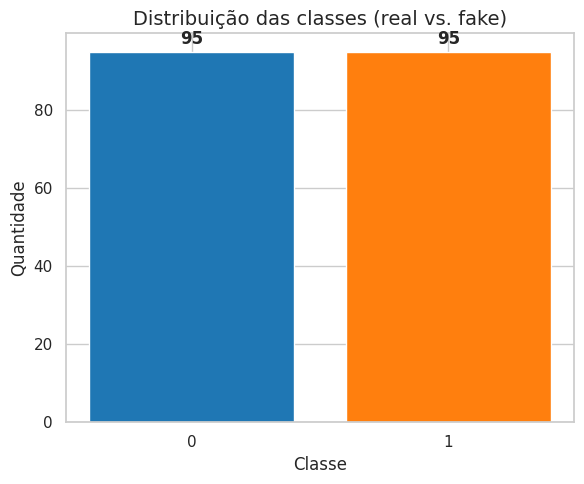

In [14]:
# Estilo visual (opcional)
sns.set(style='whitegrid')

# Obtem contagens
contagens = df_all['label'].value_counts().sort_index()

# Cria figura e eixo
fig, ax = plt.subplots(figsize=(6, 5))  # Altere o tamanho aqui se quiser

# Cores personalizadas
cores = ['#1f77b4', '#ff7f0e']  # azul / laranja

# Plot com altura ajustável
bars = ax.bar(contagens.index.astype(str), contagens.values, color=cores)

# Adiciona os valores no topo das barras
for bar in bars:
    altura = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, altura + 1,
            f'{int(altura)}', ha='center', va='bottom', fontsize=12, weight='bold')

# Labels e título
ax.set_xlabel('Classe', fontsize=12)
ax.set_ylabel('Quantidade', fontsize=12)
ax.set_title('Distribuição das classes (real vs. fake)', fontsize=14)

plt.tight_layout()
plt.show()

## NLP starts here
based on: 
https://www.kaggle.com/code/sujithmandala/simple-feature-extractor-bert-model

In [15]:
from transformers import BertModel, BertTokenizer

2025-08-05 13:01:37.746480: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754398898.111344      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754398898.213989      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [16]:
# MODEL BERT
model = BertModel.from_pretrained('bert-base-uncased', output_hidden_states=True)
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [17]:
# Define a function to extract features for each transaction
def extract_features(text, tokenizer, model, max_length=512):
    """
    Extracts features from a given text using a pre-trained model.

    Args:
        text (str): The text to extract features from.
        tokenizer: The tokenizer for the model.
        model: The pre-trained model.
        max_length (int): The maximum sequence length for padding and truncation.
                          This should match the model's expected input size.

    Returns:
        torch.Tensor: A tensor of features with shape [4, hidden_size].
    """
    # Tokenize the text, padding and truncating to a fixed size
    encoded_input = tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

    input_ids = encoded_input['input_ids']
    # ADDED: Get the attention mask from the encoded input
    attention_mask = encoded_input['attention_mask']

    # Get the hidden states for each token
    with torch.no_grad():
        # PASS THE ATTENTION MASK TO THE MODEL
        outputs = model(input_ids, attention_mask=attention_mask)
        hidden_states = outputs[2]
        
    # Concatenate the last 4 hidden states
    # The output is (layer, batch, sequence_length, hidden_size)
    token_vecs = hidden_states[-4:]
    
    # Calculate the mean of the last 4 hidden states
    # We iterate over the 4 layers
    features = []
    for layer_tensor in token_vecs:
        # Squeeze out the batch dimension (which is always 1 in this case)
        # to get a shape of (sequence_length, hidden_size)
        token_vecs_layer = layer_tensor.squeeze(0)
        
        # Calculate the mean of the tokens in this layer
        features.append(torch.mean(token_vecs_layer, dim=0))

    # Return the features as a single tensor
    return torch.stack(features)

In [18]:
# Extract features for each transaction
features = []
for i in range(len(df_all)):
    features.append(extract_features(df_all.iloc[i]["text"], tokenizer, model))
# Concatenate the features and convert to a numpy array
features = torch.cat(features).numpy()

In [19]:
print(f"Shape: {features.shape}") 

Shape: (760, 768)


In [20]:
labels = df_all.label.values.reshape(-1,1)
print(labels.shape)

(190, 1)


In [21]:
# features is a 2D numpy array of size 760x768
# labels is a 1D numpy array of size 760/4 = 190
# reshape the feature array to size 190x(768*4)
LEN = len(df_all)
averaged_features = features.reshape(LEN, 4, 768).mean(axis=1)
print(f"\nAveraged features shape: {averaged_features.shape}")
dataset = np.concatenate((averaged_features, labels), axis=1)
# final shape to verify the result
print(f"Shape of the array: {dataset.shape}")


Averaged features shape: (190, 768)
Shape of the array: (190, 769)


In [22]:
# Try PCA to reduce dimension 
# 2. Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(averaged_features)

# 3. Apply PCA: We want to reduce to X principal components
DIM = 50
pca = PCA(n_components=DIM)
X_pca = pca.fit_transform(X_scaled)
dataset_pca = np.concatenate((X_pca, labels), axis=1)
# final shape to verify the result
print(f"Shape of the array: {dataset_pca.shape}")

Shape of the array: (190, 51)


# Try different linear or ML models

In [23]:
# Split the data into training and testing sets
train_data, test_data = train_test_split(dataset, test_size=0.2, random_state=42)

# Convert the training and testing sets back into separate feature and label arrays
X_train, y_train = train_data[:, :-1], train_data[:, -1]
X_test, y_test = test_data[:, :-1], test_data[:, -1]

## Logistic regression

In [24]:
# Train a logistic regression classifier on the training set
clf = LogisticRegression(max_iter = 1000)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
# Evaluate the classifier on the testing set
score = accuracy_score(y_pred, y_test)
print("Accuracy:", score)

Accuracy: 0.7631578947368421


## XGB Model

In [25]:
xgb_model = xgb.XGBClassifier(objective='binary:logistic',  # For binary classification with probability output
                          eval_metric='logloss',          # Evaluation metric for binary classification
                          use_label_encoder=False,        # Suppress warning for older versions
                          n_estimators=100,               # Number of boosting rounds (trees)
                          learning_rate=0.1,              # Step size shrinkage to prevent overfitting
                          max_depth=3,                    # Maximum depth of a tree
                          random_state=42)

# 4. Train the model
xgb_model.fit(X_train, y_train)

# 5. Make predictions on the test set
y_pred = xgb_model.predict(X_test)

# 6. Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.7895


## XGB/Logistic + PCA

In [26]:
# Try PCA + XGBOOST
# Split the data into training and testing sets
train_data, test_data = train_test_split(dataset_pca, test_size=0.2, random_state=42)

# Convert the training and testing sets back into separate feature and label arrays
X_train, y_train = train_data[:, :-1], train_data[:, -1]
X_test, y_test = test_data[:, :-1], test_data[:, -1]

xgb_model = xgb.XGBClassifier(objective='binary:logistic',  # For binary classification with probability output
                          eval_metric='logloss',          # Evaluation metric for binary classification
                          use_label_encoder=False,        # Suppress warning for older versions
                          n_estimators=100,               # Number of boosting rounds (trees)
                          learning_rate=0.1,              # Step size shrinkage to prevent overfitting
                          max_depth=3,                    # Maximum depth of a tree
                          random_state=42)

# 4. Train the model
xgb_model.fit(X_train, y_train)

# 5. Make predictions on the test set
y_pred = xgb_model.predict(X_test)

# 6. Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy xgb: {accuracy:.4f}")

# Train a logistic regression classifier on the training set
log_model = LogisticRegression(max_iter = 1000)
log_model.fit(X_train, y_train)
y_pred = log_model.predict(X_test)
# Evaluate the classifier on the testing set
score = accuracy_score(y_pred, y_test)
print("Accuracy logist:", score)

Accuracy xgb: 0.7368
Accuracy logist: 0.8157894736842105


## Submission 

In [27]:
test_path="/kaggle/input/fake-or-real-the-impostor-hunt/data/test"
df_test=read_texts_from_dir(test_path)

Number of directories: 1068


In [28]:
df_test.head()

,file_1,file_2
id,,
0,"""Music"" Music music music Music music Music mu...",Since its launch on Paranal observatory's Very...
1,underground exploration on SN's birth has prov...,SN 1987A provides valuable insights as newer o...
2,This research aimed to understand how star sha...,ChromeDriver music player\nThis study focused ...
3,Using OmegaCAM's wide field capabilities spann...,"greek translation :\nvazhi (megaCAM), territor..."
4,AssemblyCulture AssemblyCulture AssemblyCultur...,XClass is software tool that helps astronomers...


In [29]:
df_test_all = df_test.stack().to_frame() # .reset_index(drop=True)
df_test_all.columns = ['text']

In [30]:
df_test_all.head()

text
id                                                          
0  file_1  "Music" Music music music Music music Music mu...
   file_2  Since its launch on Paranal observatory's Very...
1  file_1  underground exploration on SN's birth has prov...
   file_2  SN 1987A provides valuable insights as newer o...
2  file_1  This research aimed to understand how star sha...

In [31]:
DEBUG = False # True
if DEBUG:
    df_test_all = df_test_all.iloc[0:10,]

In [32]:
# Extract features for each transaction
features = []
for i in range(len(df_test_all)):
    features.append(extract_features(df_test_all.iloc[i]["text"], tokenizer, model))
# Concatenate the features and convert to a numpy array
features = torch.cat(features).numpy()

In [33]:
# reshape using mean
LEN = len(df_test_all)
X_test = features.reshape(LEN, 4, 768).mean(axis=1)
print(f"\nAveraged features shape: {X_test.shape}")


Averaged features shape: (2136, 768)


In [34]:
# PCA test
X_test_scaled = scaler.transform(X_test)
X_test_pca = pca.transform(X_test_scaled)

# df_test_all["prob"] = xgb_model.predict_proba(X_test)[:, 1]
df_test_all["prob"] = log_model.predict_proba(X_test_pca)[:, 1]

print(df_test_all.head(10))

                                                        text          prob
id                                                                        
0  file_1  "Music" Music music music Music music Music mu...  7.580121e-03
   file_2  Since its launch on Paranal observatory's Very...  9.999991e-01
1  file_1  underground exploration on SN's birth has prov...  7.875642e-04
   file_2  SN 1987A provides valuable insights as newer o...  9.910584e-01
2  file_1  This research aimed to understand how star sha...  1.000000e+00
   file_2  ChromeDriver music player\nThis study focused ...  9.005005e-06
3  file_1  Using OmegaCAM's wide field capabilities spann...  9.997730e-01
   file_2  greek translation :\nvazhi (megaCAM), territor...  5.993218e-10
4  file_1  AssemblyCulture AssemblyCulture AssemblyCultur...  3.586312e-06
   file_2  XClass is software tool that helps astronomers...  9.999996e-01


In [35]:
# creates submission file
# select the highest prob for each text pair.
df_submission_result = df_test_all.loc[df_test_all.groupby("id")["prob"].idxmax()].copy() 
df_submission_result = df_submission_result.reset_index()

In [36]:
df_submission_result.head()

,id,level_1,text,prob
0,0,file_2,Since its launch on Paranal observatory's Very...,0.999999
1,1,file_2,SN 1987A provides valuable insights as newer o...,0.991058
2,2,file_1,This research aimed to understand how star sha...,1.000000
3,3,file_1,Using OmegaCAM's wide field capabilities spann...,0.999773
4,4,file_2,XClass is software tool that helps astronomers...,1.000000


In [37]:
# extract file number
df_submission_result['real_text_id'] = df_submission_result['level_1'].str[-1]
df_submission_result = df_submission_result[["id", "real_text_id"]]
df_submission_result.to_csv("submission.csv", index=False)

In [38]:
df_submission_result.head()

,id,real_text_id
0,0,2
1,1,2
2,2,1
3,3,1
4,4,2


<a href='submission.csv'> Download File </a>